# <center> AI - A Guide for Thinking Humans

Python implementation of the `Perceptron` class based on the second chapter of the book:

1. **Initialization**:
  The `weights` array has `num_inputs + 1` elements to account for the inputs and the bias (threshold). Random weights are initialized.

2. **Prediction**:
  The `make_prediction` method calculates the weighted sum and applies a step function (`1 if weighted_sum >= 0 else 0`) to determine the output.

3. **Training**:
   - The `train_model` method iterates through the training data.
   - It calculates the error as `target_label - prediction` and updates the weights using the formula:
     $$ w_j \leftarrow w_j + \eta \cdot (t - y) \cdot x_j $$
   - The bias is updated using the same formula with ($x_0 = 1$).

4. **Testing**:
   Calculate model metrics using test data that the model did not see during training.
   - **Accuracy:**
    $$\text{A} = \frac{TP+TN}{TN+TP+FP+FN}$$
  - **Precision:**
    $$\text{P} = \frac{TP}{TP + FP}$$

  - **Recall (Sensitivity):**
    $$\text{R} = \frac{TP}{TP + FN}$$

  - **F1 Score:**
    $$\text{F1} = 2 \cdot \frac{\text{P} \cdot \text{R}}{\text{P} + \text{R}}$$

   - **Confusion matrix:**
    \begin{bmatrix}
    \text{TN} & \text{FP} \\
    \text{FN} & \text{TP}
    \end{bmatrix}

___

In [11]:
import numpy as np

class Perceptron:
    def __init__(self, num_inputs):
        """
        Initialize a perceptron with the number of inputs, for binary classification tasks.
        """
        self.num_inputs = num_inputs
        self.weights = np.random.randn(num_inputs+1) # Includes bias (threshold)

    def make_prediction(self, input_vector):
        """
        Make a prediction for the given input vector.

        Args: input_vector (list or np.ndarray): Input features.

        Example of input_vector:
            [
                [0.3, 0.1, ...],
                [0.0, 0.9, ...],
                [0.5, 0.7, ...],
                ...
                [0.0, 1.0, ...]
            ]

        """
        # Add the bias term (x0 = 1)
        input_with_bias = np.append(input_vector, 1)
        # Calculate the weighted sum
        weighted_sum = np.dot(self.weights, input_with_bias)
        # Apply the step function to get the output
        return 1 if weighted_sum >= 0 else 0

    def train_model(self, train_data, learning_rate):
        """
        Train the Perceptron using the provided training data.

        Args:
            - train_data (list of tuples): Each tuple contains (input_vector, target_label).
            - learning_rate (float)

        Example of train_data:
            [
                ([0.3, 0.1, ...], 0),
                ([0.0, 0.9, ...], 1),
                ([0.5, 0.7, ...], 0),
                ...
                ([0.0, 1.0, ...], 1)
            ]
        """
        for input_vector, target_label in train_data:
            # Make a prediction
            prediction = self.make_prediction(input_vector)
            # Calculate the error (t - y)
            error = target_label - prediction
            # Update weights
            input_with_bias = np.append(input_vector, 1)  # Add bias term (x0 = 1)
            self.weights += learning_rate*error*input_with_bias

In [12]:
from tensorflow.keras.datasets import mnist

# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Flatten the images
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

# Convert the labels to binary classification (True/False)
y_train = y_train==8
y_test = y_test==8

# Print the shapes of the datasets
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (60000, 784)
y_train shape: (60000,)
X_test shape: (10000, 784)
y_test shape: (10000,)


Label: False


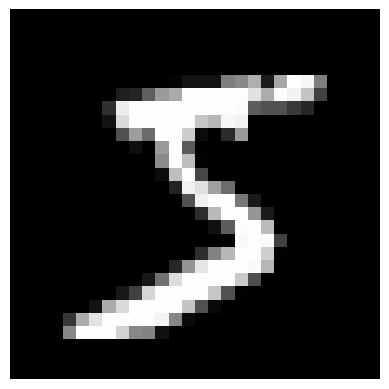

In [13]:
import matplotlib.pyplot as plt
import random

# Take a look
sample_index = random.randint(0, 1000)
sample_image = X_train[sample_index].reshape(28, 28)  # Reshape to 28x28 for visualization
sample_label = y_train[sample_index]

print(f"Label: {sample_label}")
plt.imshow(sample_image, cmap='gray')
plt.axis('off')
plt.show()

In [14]:
# Transform X and y arrays to list of tuples (input_vector, target_label)
def data_pipeline(X, y):
    data = [
        (input_vector.tolist(), int(label))  # Convert input_vector to list and label to int
        for input_vector, label in zip(X, y)
    ]
    return data

train_data = data_pipeline(X_train, y_train)
test_data = data_pipeline(X_test, y_test)

# Create a Perceptron with 64 inputs
num_inputs = 28*28 # 784 pixels
perceptron = Perceptron(num_inputs=num_inputs)

# Train the Perceptron
for epoch in range(10):  # Train for 10 epochs
    perceptron.train_model(train_data, learning_rate=0.01)

In [19]:
from sklearn.metrics import classification_report, confusion_matrix

predictions = []
true_labels = []

# Make predictions and collect true labels
for input_vector, target_label in test_data:
    prediction = perceptron.make_prediction(input_vector)
    predictions.append(prediction)
    true_labels.append(target_label)

# Compute the classification report
class_report = classification_report(true_labels, predictions, target_names=['no-8', '8'])
print("Classification Report:\n")
print(class_report)

# Compute the confusion matrix
conf_matrix = confusion_matrix(true_labels, predictions)
print("Confusion Matrix:\n")
print(conf_matrix)

Classification Report:

              precision    recall  f1-score   support

        no-8       0.96      0.92      0.94      9026
           8       0.47      0.64      0.54       974

    accuracy                           0.89     10000
   macro avg       0.72      0.78      0.74     10000
weighted avg       0.91      0.89      0.90     10000

Confusion Matrix:

[[8320  706]
 [ 346  628]]
